# Stroke Prediction Using Classification Algorithms

This notebook explores the use of seven different classification algorithms to predict strokes based on patient data. The dataset is provided by the WHO and includes demographic and health-related features.

We will:
- Perform data preprocessing and encoding
- Handle missing values and class imbalance (using SMOTE)
- Train seven classifiers
- Evaluate using accuracy and F1-score
- Plot confusion matrix heatmaps for best models

In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from imblearn.over_sampling import SMOTE

In [5]:
df = pd.read_csv('healthcare-dataset-stroke-data.csv')
df.drop('id', axis=1, inplace=True)

df['bmi'] = df['bmi'].fillna(df['bmi'].median())

le = LabelEncoder()
for col in ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']:
    df[col] = le.fit_transform(df[col])

df.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,1,67.0,0,1,1,2,1,228.69,36.6,1,1
1,0,61.0,0,0,1,3,0,202.21,28.1,2,1
2,1,80.0,0,1,1,2,0,105.92,32.5,2,1
3,0,49.0,0,0,1,2,1,171.23,34.4,3,1
4,0,79.0,1,0,1,3,0,174.12,24.0,2,1


## Exploratory Data Analysis (EDA)

In [6]:
print("Shape:", df.shape)
display(df.dtypes)
display(df.describe(include='all').T)

print("\nMissing values:\n", df.isna().sum())
print("Shape:", df.shape)
print('Duplicate rows:', df.duplicated().sum())

stroke_dist = df['stroke'].value_counts(normalize=True) * 100
print("\nStroke class distribution (%):\n", stroke_dist)

Shape: (5110, 11)


gender                 int64
age                  float64
hypertension           int64
heart_disease          int64
ever_married           int64
work_type              int64
Residence_type         int64
avg_glucose_level    float64
bmi                  float64
smoking_status         int64
stroke                 int64
dtype: object

,count,mean,std,min,25%,50%,75%,max
gender,5110.0,0.414286,0.493044,0.00,0.000,0.000,1.00,2.00
age,5110.0,43.226614,22.612647,0.08,25.000,45.000,61.00,82.00
hypertension,5110.0,0.097456,0.296607,0.00,0.000,0.000,0.00,1.00
heart_disease,5110.0,0.054012,0.226063,0.00,0.000,0.000,0.00,1.00
ever_married,5110.0,0.656164,0.475034,0.00,0.000,1.000,1.00,1.00
work_type,5110.0,2.167710,1.090293,0.00,2.000,2.000,3.00,4.00
Residence_type,5110.0,0.508023,0.499985,0.00,0.000,1.000,1.00,1.00
avg_glucose_level,5110.0,106.147677,45.283560,55.12,77.245,91.885,114.09,271.74
bmi,5110.0,28.862035,7.699562,10.30,23.800,28.100,32.80,97.60
smoking_status,5110.0,1.376908,1.071534,0.00,0.000,2.000,2.00,3.00



Missing values:
 gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64
Shape: (5110, 11)
Duplicate rows: 0

Stroke class distribution (%):
 stroke
0    95.127202
1     4.872798
Name: proportion, dtype: float64


## Data Preparation

As the dataset is already clean, we will directly proceed to the next steps. We will split the data into training and testing sets, and then apply SMOTE to handle class imbalance since the dataset is formed of 95% non-stroke patients and 5% stroke patients. 

In [7]:
X = df.drop('stroke', axis=1)
y = df['stroke']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Apply SMOTE to handle class imbalance
sm = SMOTE(random_state=42)
X_train, y_train = sm.fit_resample(X_train, y_train)

## Train and Evaluate Models

In [8]:
results = {}
predictions = {}

### Logistic Regression


In [9]:
lr = LogisticRegression()
lr.fit(X_train, y_train)
pred = lr.predict(X_test)
results['Logistic Regression'] = classification_report(y_test, pred, output_dict=True)
predictions['Logistic Regression'] = pred

### K-Nearest Neighbors (KNN)


In [10]:
knn = KNeighborsClassifier(n_neighbors=10, weights='distance')
knn.fit(X_train, y_train)
pred = knn.predict(X_test)
results['KNN'] = classification_report(y_test, pred, output_dict=True)
predictions['KNN'] = pred

### Decision Tree Classifier


In [11]:
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)
pred = dt.predict(X_test)
results['Decision Tree'] = classification_report(y_test, pred, output_dict=True)
predictions['Decision Tree'] = pred

### Random Forest Classifier


In [12]:
rf = RandomForestClassifier()
rf.fit(X_train, y_train)
pred = rf.predict(X_test)
results['Random Forest'] = classification_report(y_test, pred, output_dict=True)
predictions['Random Forest'] = pred

### Support Vector Classifier (SVC)


In [13]:
svc = SVC()
svc.fit(X_train, y_train)
pred = svc.predict(X_test)
results['SVC'] = classification_report(y_test, pred, output_dict=True)
predictions['SVC'] = pred

### Naive Bayes Classifier


In [14]:
nb = GaussianNB()
nb.fit(X_train, y_train)
pred = nb.predict(X_test)
results['Naive Bayes'] = classification_report(y_test, pred, output_dict=True)
predictions['Naive Bayes'] = pred

### Gradient Boosting Classifier


In [15]:
gb = GradientBoostingClassifier()
gb.fit(X_train, y_train)
pred = gb.predict(X_test)
results['Gradient Boosting'] = classification_report(y_test, pred, output_dict=True)
predictions['Gradient Boosting'] = pred

## Comparative Evaluation

,Model,Accuracy,F1-Score (stroke=1)
6,Gradient Boosting,0.875734,0.298343
0,Logistic Regression,0.761252,0.246914
5,Naive Bayes,0.735812,0.210526
4,SVC,0.767123,0.195946
1,KNN,0.789628,0.176245
3,Random Forest,0.924658,0.153846
2,Decision Tree,0.892368,0.140625


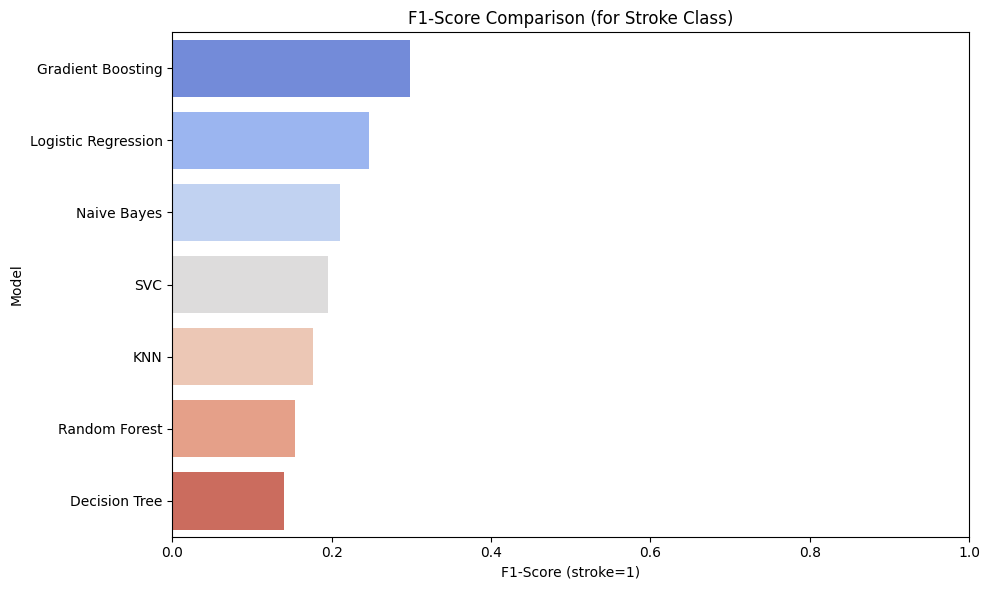

In [21]:
summary = []
for model_name, report in results.items():
    acc = report['accuracy']
    f1_stroke = report['1']['f1-score'] if '1' in report else 0
    summary.append({
        'Model': model_name,
        'Accuracy': acc,
        'F1-Score (stroke=1)': f1_stroke
    })

summary_df = pd.DataFrame(summary).sort_values(by='F1-Score (stroke=1)', ascending=False)
display(summary_df)

plt.figure(figsize=(10,6))
sns.barplot(x='F1-Score (stroke=1)', y='Model', data=summary_df, hue='Model', palette='coolwarm', legend=False)
plt.title('F1-Score Comparison (for Stroke Class)')
plt.xlabel('F1-Score (stroke=1)')
plt.xlim(0,1)
plt.tight_layout()
plt.show()

## Confusion Matrix Heatmaps (Top 3 Models)

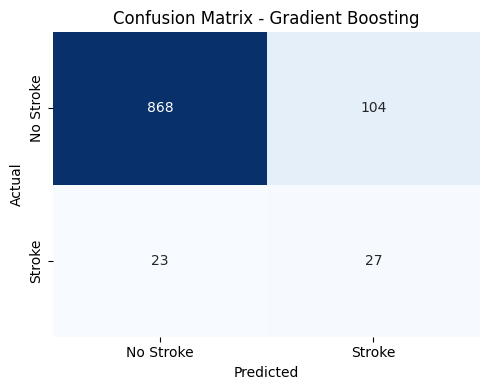

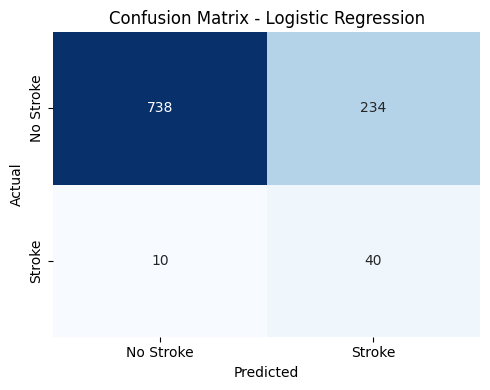

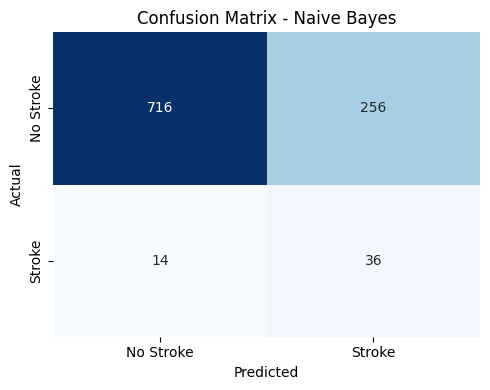

In [17]:
top_3 = summary_df.head(3)['Model'].tolist()

for model_name in top_3:
    cm = confusion_matrix(y_test, predictions[model_name])
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['No Stroke', 'Stroke'],
                yticklabels=['No Stroke', 'Stroke'])
    plt.title(f'Confusion Matrix - {model_name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.show()